بسم الله

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [2]:
df = pd.read_csv("/kaggle/input/amazon-stock-prices1997-2021/AMZN.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,0.071354,377064000


In [3]:
df.shape

(6516, 7)

In [4]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
6511,2023-03-30,101.550003,103.040001,101.010002,102.000000,102.000000,53633400
6512,2023-03-31,102.160004,103.489998,101.949997,103.290001,103.290001,56704300
6513,2023-04-03,102.300003,103.290001,101.430000,102.410004,102.410004,41135700
6514,2023-04-04,102.750000,104.199997,102.110001,103.949997,103.949997,48662500
6515,2023-04-05,103.910004,103.910004,100.750000,101.099998,101.099998,45103000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6516 entries, 0 to 6515
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       6516 non-null   object 
 1   Open       6516 non-null   float64
 2   High       6516 non-null   float64
 3   Low        6516 non-null   float64
 4   Close      6516 non-null   float64
 5   Adj Close  6516 non-null   float64
 6   Volume     6516 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 356.5+ KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,6516.0,3.161163e+01,4.809534e+01,7.031300e-02,1.998875e+00,6.456750e+00,3.845137e+01,1.872000e+02
High,6516.0,3.199200e+01,4.865965e+01,7.239600e-02,2.028500e+00,6.535500e+00,3.868800e+01,1.886540e+02
Low,6516.0,3.119343e+01,4.746448e+01,6.562500e-02,1.964750e+00,6.353250e+00,3.820300e+01,1.848395e+02
Close,6516.0,3.159974e+01,4.806026e+01,6.979200e-02,2.001250e+00,6.444250e+00,3.846463e+01,1.865705e+02
Adj Close,6516.0,3.159974e+01,4.806026e+01,6.979200e-02,2.001250e+00,6.444250e+00,3.846463e+01,1.865705e+02
Volume,6516.0,1.425338e+08,1.401619e+08,9.744000e+06,6.888182e+07,1.059050e+08,1.607700e+08,2.086584e+09


<Axes: >

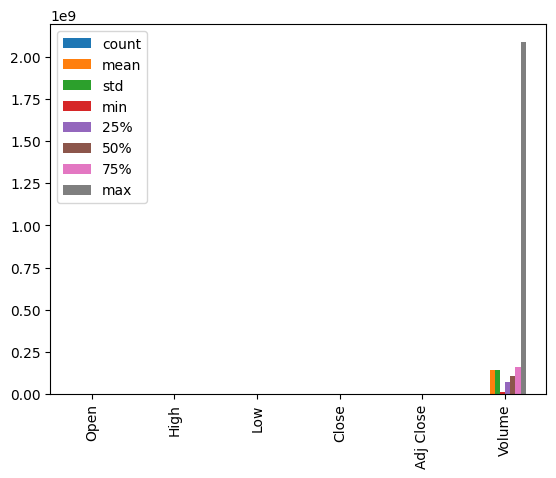

In [7]:
df.describe().T.plot(kind='bar')

In [8]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,0.121875,0.125000,0.096354,0.097917,0.097917,1443120000
1,1997-05-16,0.098438,0.098958,0.085417,0.086458,0.086458,294000000
2,1997-05-19,0.088021,0.088542,0.081250,0.085417,0.085417,122136000
3,1997-05-20,0.086458,0.087500,0.081771,0.081771,0.081771,109344000
4,1997-05-21,0.081771,0.082292,0.068750,0.071354,0.071354,377064000
...,...,...,...,...,...,...,...
6511,2023-03-30,101.550003,103.040001,101.010002,102.000000,102.000000,53633400
6512,2023-03-31,102.160004,103.489998,101.949997,103.290001,103.290001,56704300
6513,2023-04-03,102.300003,103.290001,101.430000,102.410004,102.410004,41135700
6514,2023-04-04,102.750000,104.199997,102.110001,103.949997,103.949997,48662500


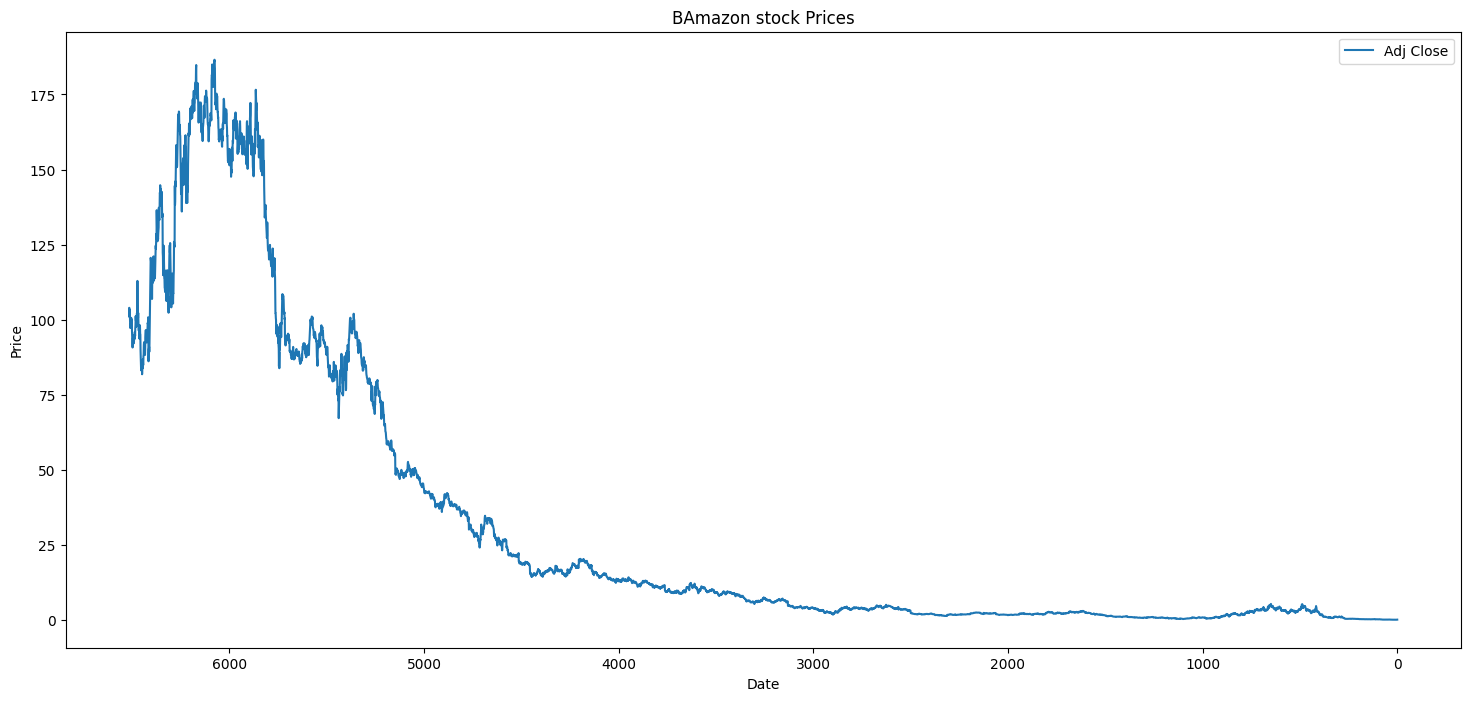

In [9]:
df[['Date', 'Adj Close']].plot(figsize=(18, 8))

plt.title('BAmazon stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().invert_xaxis()

plt.show()

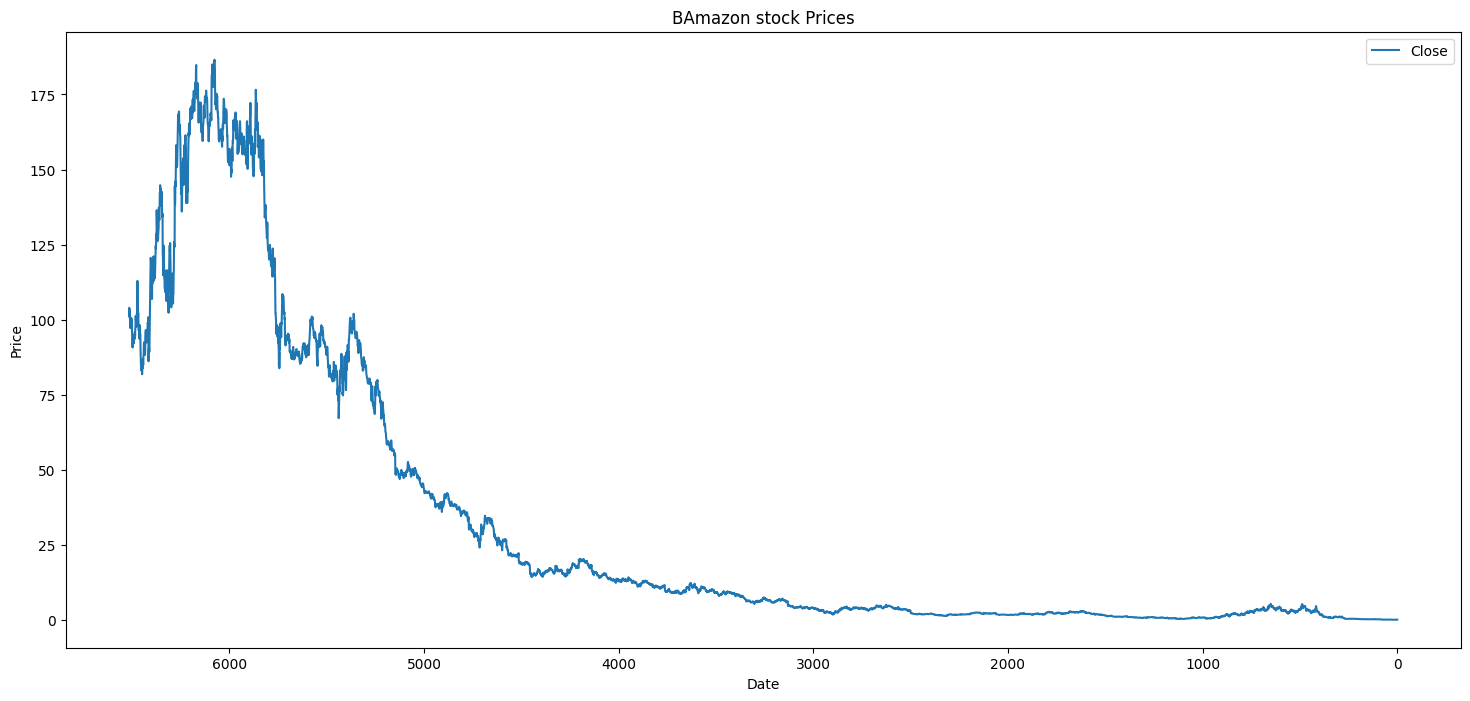

In [10]:
df[['Date', 'Close']].plot(figsize=(18, 8))

plt.title('BAmazon stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.gca().invert_xaxis()

plt.show()

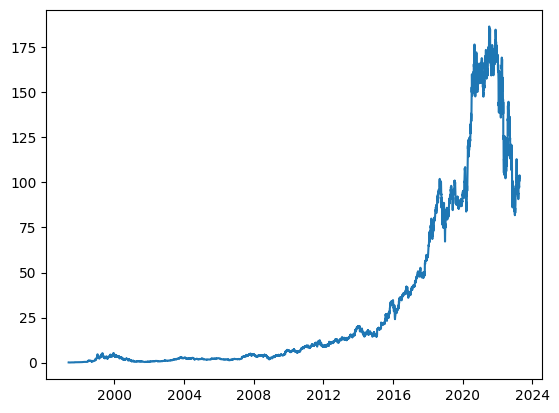

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

# Lets plot the date against the close .
plt.plot(df['Date'] , df['Close'])

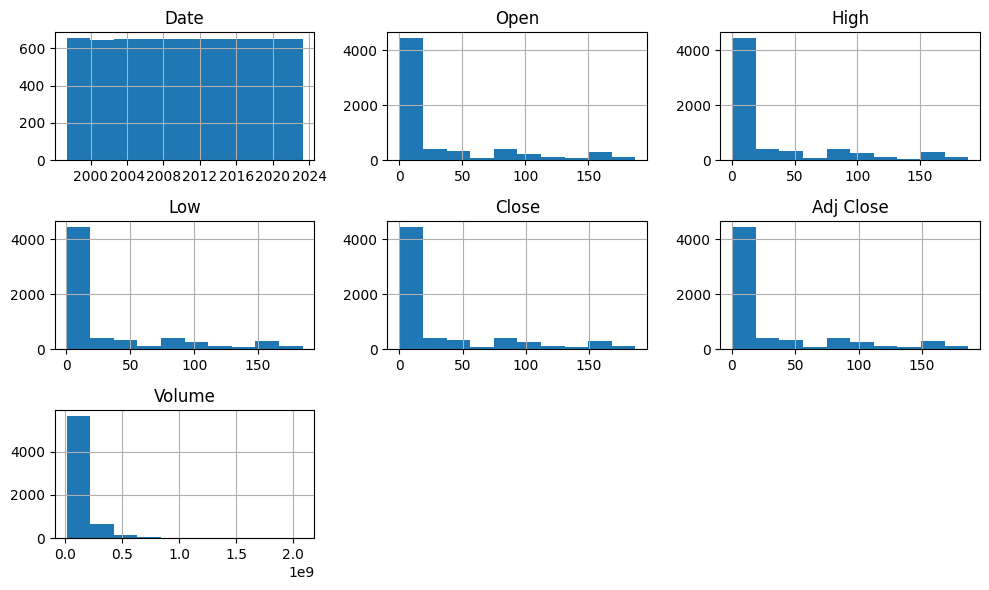

In [12]:
df = pd.DataFrame(df)

# رسم الهيستوجرام باستخدام pandas
df.hist(figsize=(10, 6))
plt.tight_layout()  # تحسين التخطيط
plt.show()

In [13]:
from plotly.express import imshow
imshow(img=df.corr(numeric_only=True))

In [14]:
df.columns.to_list()

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

In [15]:
import plotly.express as px
import pandas as pd

# Example data (replace with your actual data)
data = {
    'Date': pd.date_range('2023-01-01', periods=100),
    'Open': pd.Series(range(100)),
    'High': pd.Series(range(100, 200)),
    'Low': pd.Series(range(50, 150)),
    'Close': pd.Series(range(90, 190)),
    'Adj Close': pd.Series(range(85, 185)),
    'Volume': pd.Series(range(1000, 1100))
}

# Create DataFrame
df = pd.DataFrame(data)

# List of columns
columns = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

# Using Plotly Express to create scatter matrix
fig = px.scatter_matrix(df[columns])

# Show plot
fig.show()


In [16]:
import plotly.graph_objects as go
import pandas as pd

# Example data (replace with your actual data)
data = {
    'Date': pd.date_range('2023-01-01', periods=100),
    'Close': pd.Series(range(100))
}

df = pd.DataFrame(data)

# Create a line plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=df['Date'], y=df['Close'], mode='lines', name='Close'))

# Customize layout
fig.update_layout(title='Stock Close Prices Over Time',
                  xaxis_title='Date',
                  yaxis_title='Close Price')

# Show plot
fig.show()
